In [124]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


In [125]:
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# functions that need to move to tweezer_functions.py


In [126]:
def tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_list,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
    qubit_lambda=729e-9,
):
    """
    As before, but compute k = 2*pi/qubit_lambda and scale eigenvectors by
    k * sqrt(hbar / (2 * m * omega_mode)), where omega_mode = 2*pi*freq_Hz.
    """

    if np.isscalar(N_list):
        N_list = [int(N_list)]
    if np.isscalar(P_opt):
        P_opt = [P_opt]

    pi = np.pi
    rows = []
    # compute k from provided qubit wavelength and base scale
    k = 2 * pi / qubit_lambda
    eigvec_scale = k * np.sqrt(hbar / (2 * m))

    for N in N_list:
        # Generate all possible tweezer combinations, but only over the first N/2 ions
        half_range = N // 2 +1
        max_tweezed_local = min(max_tweezed, half_range)
        all_positions = range(half_range)
        all_combos = []
        for r in range(0, max_tweezed_local + 1):
            all_combos.extend(itertools.combinations(all_positions, r))

        w_rf_r = f_rf_r * 2 * pi
        w_rf_r_list = np.full(N, w_rf_r)
        ueq = ion_spacing(N, f_rf_a)[0]

        for P_total in P_opt:
            for tweezed_positions in all_combos:
                n_tweezed = len(tweezed_positions)
                P_per = P_total / n_tweezed if n_tweezed > 0 else 0.0

                pot = potential(omega_tweezer, linewidths, omega_res, P_per, w0)
                w_tw_r = omega_tweezer_r(pot, w0, m)

                combo = np.array([
                    np.sqrt(w_tw_r**2 + w_rf_r_list[i]**2) if i in tweezed_positions else w_rf_r_list[i]
                    for i in range(N)
                ])

                modes = mode_calc_r(m, combo, ueq, N)

                freqs = np.array([f for f, v in modes], dtype=float) if len(modes) else np.array([], dtype=float)
                if len(modes):
                    eigvecs = np.vstack([np.ravel(v) for f, v in modes])
                else:
                    eigvecs = np.empty((0, N))

                row = {
                    "N": N,
                    "Tweezed ions": tweezed_positions,
                    "P_per_tweezer (W)": P_per,
                    "Combined radial frequencies": combo,
                }

                for mode_index in range(N):
                    if mode_index < len(freqs):
                        freq_val = float(freqs[mode_index])  # freq in Hz as returned by mode_calc_r
                        row[f"Mode{mode_index}_freq"] = freq_val
                    else:
                        freq_val = np.nan
                        row[f"Mode{mode_index}_freq"] = np.nan

                    if mode_index < eigvecs.shape[0] and not np.isnan(freq_val) and freq_val > 0:
                        # convert to angular frequency (rad/s)
                        omega_mode = 2.0 * pi * freq_val
                        # final scale uses angular frequency (zero-point amplitude)
                        scale = eigvec_scale * np.sqrt(1.0 / omega_mode)
                        row[f"Mode{mode_index}_eigvec"] = np.ravel(eigvecs[mode_index]).astype(float) * scale
                    else:
                        row[f"Mode{mode_index}_eigvec"] = np.full(N, np.nan, dtype=float)

                rows.append(row)

    return pd.DataFrame(rows)

In [127]:
def combine_lists_same_index(*lists):
    """
    Fully general N-dimensional version that iterates over
    the SAME element index across all lists.
    
    Input: List of modes, each containing [(key, array), ...]
    Output: Dictionary where each key maps to [(key, index, combined_array), ...]
    
    For each key and element index, combines values from that index
    across all input lists.
    """
    
    # Number of lists (N)
    N = len(lists)
    
    # Length of the vectors (K)
    K = len(lists[0][0][1])
    
    # Collect all distinct original indices
    keys = [idx for idx, _ in lists[0]]
    
    # Map each list by idx for fast lookup
    idx_maps = []
    for lst in lists:
        idx_maps.append({idx: arr for idx, arr in lst})
    
    # Storage for output groups
    groups = {key: [] for key in keys}
    
    # Loop over each index group
    for key in keys:
        
        # Grab the vector chosen from each list for this group
        chosen = [idx_maps[m][key] for m in range(N)]
        
        # Sweep SAME element index across all lists
        for elem_idx in range(K):
            
            # Collect this element from all modes for this key
            values = np.array([chosen[m][elem_idx] for m in range(N)])
            
            # Store tuple
            groups[key].append(
                (key, elem_idx, values)
            )
    
    return groups

In [128]:

def midcircuit_modes_test(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     f_rf_a,
                     P,
                     w0
                     ):
    """
    Compute combined mode lists for all tweezed configurations for given N.
    Returns a DataFrame of best rows (keeps all top-scoring rows, removes lower losers).
    NOTE: Tweezed Ion may equal Coolant Ion (this function allows that).
    """
    results = tweezer_combos_full_radial_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
        max_tweezed=1,
    )
    result = build_mode_series_and_combinations(results)

    mode_list_test = list(result["mode_lists"].values())
    
    # Convert mode lists to DataFrame using combine_lists_same_index
    combined_dict = combine_lists_same_index(*mode_list_test)
    
    # Convert the dictionary of lists into a DataFrame
    rows = []
    for key, entries in combined_dict.items():
        for k, elem_idx, values in entries:
            rows.append({
                "Tweezed Ion": key,
                "Coolant Ion": elem_idx,
                "Mode couplings": values
            })
    
    middle = pd.DataFrame(rows)
    
    if middle.empty:
        return middle
    
    # Add inverse and sum columns
    middle["inverse_mode_couplings"] = middle["Mode couplings"].apply(
        lambda arr: np.array([1.0/abs(x) if x != 0 else np.inf for x in arr])
    )
    middle["sum_inverse_middle"] = middle["inverse_mode_couplings"].apply(
        lambda lst: float(np.nansum(lst))
    )

    # NOTE: we intentionally allow Tweezed Ion == Coolant Ion here (no filtering).

    # collect best per tweezed-ion group (choose canonical one per group)
    best_rows = middle.iloc[0:0].copy()
    tweezed_keys = [k for k in middle["Tweezed Ion"].unique() if pd.notna(k)]
    for key in tweezed_keys:
        subset = middle[middle["Tweezed Ion"] == key]
        if subset.empty:
            continue
        # keep subset as-is (allow coolant == tweezed)
        mn = subset["sum_inverse_middle"].abs().min()
        mask = np.isclose(subset["sum_inverse_middle"].abs(), mn, rtol=1e-12, atol=1e-12)
        tied = subset.loc[mask]
        # pick canonical representative (first by Coolant Ion, NaN last)
        chosen = tied.sort_values("Coolant Ion", na_position="last").iloc[0:1]
        best_rows = pd.concat([best_rows, chosen], ignore_index=True)

    # keep only the globally best score(s) across all tweezed groups
    if best_rows.empty:
        return best_rows

    global_min = best_rows["sum_inverse_middle"].abs().min()
    keep_mask = np.isclose(best_rows["sum_inverse_middle"].abs(), global_min, rtol=1e-8, atol=1e-12)
    final = best_rows.loc[keep_mask].reset_index(drop=True)

    return final

# ...existing code...
# ...existing code...
def sweep_power_and_find_minima(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    Ns_to_sweep,
    f_rf_r,
    f_rf_a,
    w0,
    power_values,
):
    """
    Sweep power values for given N values and find minimum tweezed/untweezed ratio.
    
    Parameters:
    -----------
    omega_tweezer, linewidths, omega_res, m, mode_calc_r : system parameters
    Ns_to_sweep : list of N values to evaluate
    f_rf_r, f_rf_a, w0 : RF and tweezer parameters
    power_values : array of power values (in watts) to sweep
    
    Returns:
    --------
    Dictionary with keys:
        't_vals': dict mapping N to list of tweezed metric values
        'u_vals': dict mapping N to list of untweezed metric values
        'ratio_vals': dict mapping N to list of ratio values
        'min_power_indices': dict mapping N to (min_power_mW, min_ratio)
        'power_values': the input power array for reference
    """
    
    def first_sum_by_N(df):
        if df is None or df.empty:
            return np.array([]), np.array([])
        first = df.groupby("N", sort=True, as_index=False).first()
        return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()
    
    # prepare containers per N
    t_vals = {N: [] for N in Ns_to_sweep}
    u_vals = {N: [] for N in Ns_to_sweep}
    ratio_vals = {N: [] for N in Ns_to_sweep}
    
    # sweep through power values
    for p in power_values:
        P_current = [p]
        for N_fixed in Ns_to_sweep:
            # tweezed
            test_loop = midcircuit_modes_test(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, f_rf_a, P_current, w0
            )
            if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
                df = test_loop.copy().reset_index(drop=True)
                df['N'] = int(N_fixed)
                try:
                    df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
                except Exception:
                    pass
                dfs = [df]
            else:
                dfs = []
            
            # untweezed
            test_loop_u = midcircuit_modes_untweezed_test(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, f_rf_a, P_current, w0
            )
            if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
                dfu = test_loop_u.copy().reset_index(drop=True)
                dfu['N'] = int(N_fixed)
                try:
                    dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
                except Exception:
                    pass
                dfs_untweezed = [dfu]
            else:
                dfs_untweezed = []
            
            combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
            combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()
            
            _, vals_t_arr = first_sum_by_N(combined_df)
            _, vals_u_arr = first_sum_by_N(combined_untweezed)
            
            val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
            val_u = vals_u_arr[0] if vals_u_arr.size else np.nan
            
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))
            
            t_vals[N_fixed].append(val_t)
            u_vals[N_fixed].append(val_u)
            ratio_vals[N_fixed].append(ratio)
    
    # Find minimum ratio for each N
    min_power_indices = {}
    for N_fixed in Ns_to_sweep:
        ratio_list = ratio_vals[N_fixed]
        min_ratio = np.nanmin(ratio_list)
        min_idx = np.nanargmin(ratio_list)
        min_power_mW = power_values[min_idx] * 1e3
        min_power_indices[N_fixed] = (min_power_mW, min_ratio)
    
    return {
        't_vals': t_vals,
        'u_vals': u_vals,
        'ratio_vals': ratio_vals,
        'min_power_indices': min_power_indices,
        'power_values': power_values,
    }


def midcircuit_modes_untweezed_test(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     f_rf_a,
                     P,
                     w0
                     ):
    """
    Untweezed version: use combine_lists_same_index_df_untweezed and pick global best(s).
    Ensures:
      - "inverse_mode_couplings" stores 1 / abs(mode_coupling) for each entry
      - "sum_inverse_middle" is the sum of those inverses for the row
    """
    results = tweezer_combos_full_radial_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
        max_tweezed=0,
    )
    result = build_mode_series_and_combinations(results)

    mode_list_test = list(result["mode_lists"].values())
    
    # Convert mode lists to DataFrame using combine_lists_same_index
    combined_dict = combine_lists_same_index(*mode_list_test)
    
    # Convert the dictionary of lists into a DataFrame
    rows = []
    for key, entries in combined_dict.items():
        for k, elem_idx, values in entries:
            rows.append({
                "Tweezed Ion": key,
                "Coolant Ion": elem_idx,
                "Mode couplings": values
            })
    
    middle = pd.DataFrame(rows)

    if middle.empty:
        return middle

    # inverse_mode_couplings = 1 / abs(value) for each entry in Mode couplings
    def inv_abs_list(arr):
        # arr may be list-like or numpy array; try to handle mixed/invalid entries robustly
        try:
            a = np.array([float(x) for x in arr], dtype=float)
        except Exception:
            # fallback: iterate and coerce elementwise (preserve invalid as np.nan)
            out = []
            for x in arr:
                try:
                    out.append(float(x))
                except Exception:
                    out.append(np.nan)
            a = np.array(out, dtype=float)

        a = np.abs(a)
        with np.errstate(divide="ignore", invalid="ignore"):
            inv = np.where(np.isnan(a), np.nan, np.where(a == 0.0, np.inf, 1.0 / a))
        return inv.astype(float)

    # store the actual inverses of the absolute couplings
    middle["inverse_mode_couplings"] = middle["Mode couplings"].apply(inv_abs_list)

    # sum_inverse_middle = sum of those inverses (treat NaN as missing, include np.inf if present)
    middle["sum_inverse_middle"] = middle["inverse_mode_couplings"].apply(lambda arr: float(np.nansum(arr)))

    # select rows with minimal sum_inverse_middle (best candidate(s))
    global_min = middle["sum_inverse_middle"].abs().min()
    keep_mask = np.isclose(middle["sum_inverse_middle"].abs(), global_min, rtol=1e-8, atol=1e-12)
    final = middle.loc[keep_mask].reset_index(drop=True)
    return final

def collect_midcircuit_combined_df_test(
    Ns,
    omega_t,
    linewidths_,
    omega_res_,
    m_,
    mode_calc,
    f_rf_r_,
    f_rf_a_,
    P_,
    w0_,
    return_many_N=False,
):
    """
    Run midcircuit_modes for each N in Ns and return a combined DataFrame.
    Does NOT print or display per-N results. Keeps all rows (no per-N dedupe).
    If return_many_N is True, also return the list of (N, per-N DataFrame).
    """
    dfs = []
    many_N = []

    for N in Ns:
        test_loop = midcircuit_modes_test(
            omega_t,
            linewidths_,
            omega_res_,
            m_,
            mode_calc,
            N,
            f_rf_r_,
            f_rf_a_,
            P_,
            w0_,
        )
        many_N.append((N, test_loop))

        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df["N"] = int(N)
            try:
                df["Tweezed Ion"] = df["Tweezed Ion"].astype(int)
            except Exception:
                pass
            dfs.append(df)

    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True, sort=False)
        cols = [
            "N",
            "Tweezed Ion",
            "Coolant Ion",
            "Mode couplings",
            "inverse_mode_couplings",
            "sum_inverse_middle",
        ]
        combined_df = combined_df[[c for c in cols if c in combined_df.columns]]
    else:
        combined_df = pd.DataFrame()

    if return_many_N:
        return combined_df, many_N
    return combined_df

# testing of functions

In [129]:
midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        3,
        f_rf_r,
        f_rf_a,
        1e-3,
        w0,
    )

,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,1.0,0,"[-0.05285882810862266, -0.06858435881036191, 0.04368580422859225]","[18.918315743683195, 14.580583931170576, 22.890731157594267]",56.389631


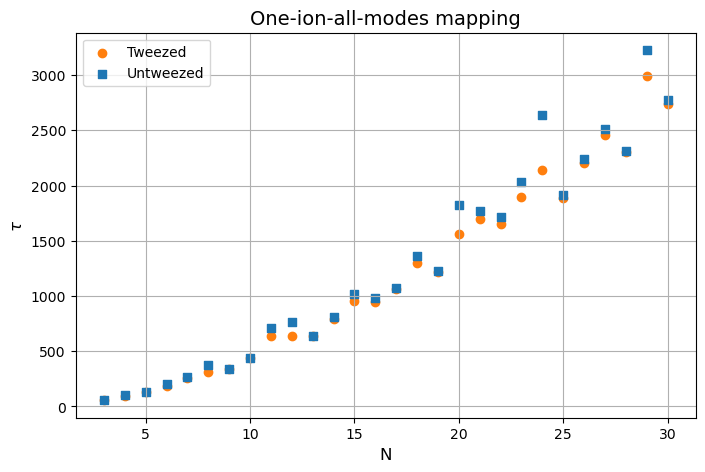

In [130]:
N = np.arange(3,4)
P = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

dfs = []
many_N = []

for N in range(3, 31):
    test_loop = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)



# ...existing code...
dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 31):
    test_loop = midcircuit_modes_untweezed_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)
# combine per-N DataFrames if not already done

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.scatter(Ns_t, vals_t, marker='o', color='C1', label='Tweezed')
if Ns_u.size:
    plt.scatter(Ns_u, vals_u, marker='s', color='C0', label='Untweezed')
plt.xlabel("N",fontsize = 12)
plt.ylabel(r"$\tau$", fontsize=12)
plt.title("One-ion-all-modes mapping",fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

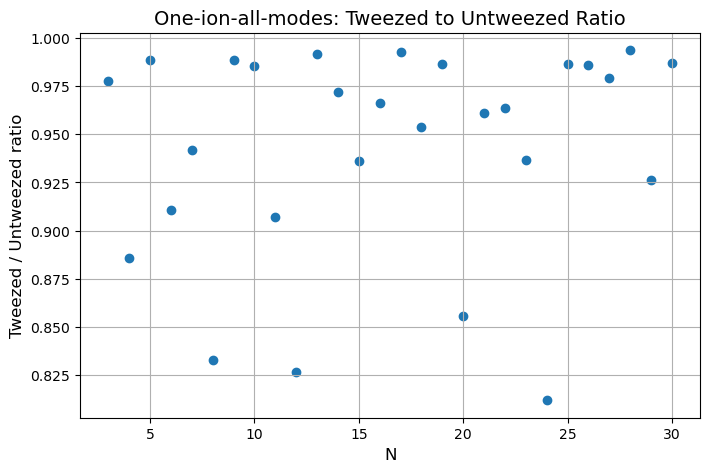

In [131]:
# Calculate ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratio_vals = []

for N in common_N:
    idx_t = np.where(Ns_t == N)[0]
    idx_u = np.where(Ns_u == N)[0]
    if len(idx_t) > 0 and len(idx_u) > 0:
        val_t = vals_t[idx_t[0]]
        val_u = vals_u[idx_u[0]]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = val_t / val_u if val_u != 0 else np.nan
        ratio_vals.append(ratio)
    else:
        ratio_vals.append(np.nan)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(common_N, ratio_vals, marker='o')
plt.xlabel("N", fontsize=12)
plt.ylabel(r"Tweezed / Untweezed ratio", fontsize=12)
plt.title("One-ion-all-modes: Tweezed to Untweezed Ratio", fontsize=14)
plt.grid(True)
#plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Ratio = 1')
#plt.legend()
plt.show()

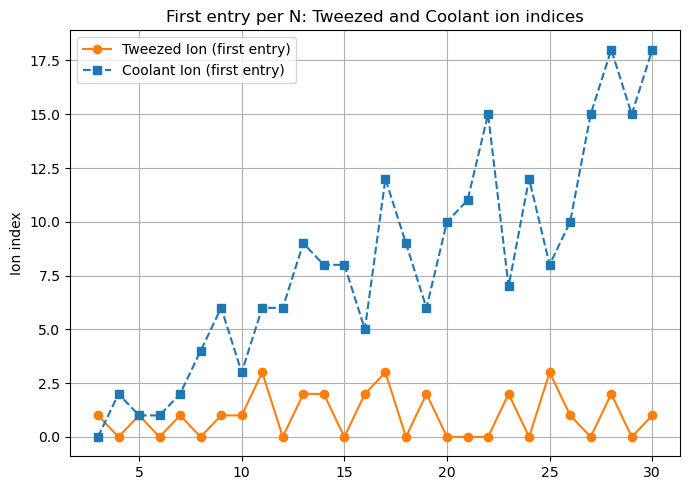

In [132]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _get_df_for_N(many, combined, N):
    if isinstance(many, list):
        for n, item in many:
            if n == N:
                if isinstance(item, pd.DataFrame):
                    return item.copy().reset_index(drop=True)
                return None
    if isinstance(combined, pd.DataFrame) and not combined.empty:
        tmp = combined[combined['N'] == N]
        if not tmp.empty:
            return tmp.copy().reset_index(drop=True)
    return None

many = globals().get('many_N')
combined = globals().get('combined_df')

if isinstance(many, list) and many:
    Ns = sorted({n for n, _ in many})
elif isinstance(combined, pd.DataFrame) and not combined.empty and 'N' in combined.columns:
    Ns = sorted(combined['N'].unique())
else:
    Ns = list(range(3, 30))

Ns = list(Ns)
first_t = []
first_c = []
second_t = []
second_c = []

for N in Ns:
    df = _get_df_for_N(many, combined, N)
    if df is None or df.empty:
        first_t.append(np.nan); first_c.append(np.nan)
        second_t.append(np.nan); second_c.append(np.nan)
        continue

    def safe_int(x):
        try:
            return int(x)
        except Exception:
            try:
                return int(float(x))
            except Exception:
                return np.nan

    # first entry (row 0)
    r0 = df.iloc[0]
    first_t.append(safe_int(r0.get('Tweezed Ion', np.nan)))
    first_c.append(safe_int(r0.get('Coolant Ion', np.nan)))

    # second entry (row 1) if available
    if len(df) > 1:
        r1 = df.iloc[1]
        second_t.append(safe_int(r1.get('Tweezed Ion', np.nan)))
        second_c.append(safe_int(r1.get('Coolant Ion', np.nan)))
    else:
        second_t.append(np.nan); second_c.append(np.nan)

# Plot
fig, axes = plt.subplots(1, 1, figsize=(7,5), sharex=True)

axes.plot(Ns, first_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (first entry)')
axes.plot(Ns, first_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (first entry)')
axes.set_ylabel('Ion index')
axes.set_title('First entry per N: Tweezed and Coolant ion indices')
axes.grid(True)
axes.legend()




plt.tight_layout()
plt.show()


In [133]:
list(zip(first_t, first_c))

[(1, 0),
 (0, 2),
 (1, 1),
 (0, 1),
 (1, 2),
 (0, 4),
 (1, 6),
 (1, 3),
 (3, 6),
 (0, 6),
 (2, 9),
 (2, 8),
 (0, 8),
 (2, 5),
 (3, 12),
 (0, 9),
 (2, 6),
 (0, 10),
 (0, 11),
 (0, 15),
 (2, 7),
 (0, 12),
 (3, 8),
 (1, 10),
 (0, 15),
 (2, 18),
 (0, 15),
 (1, 18)]

In [134]:
def sweep_power_and_find_minima(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    Ns_to_sweep,
    f_rf_r,
    f_rf_a,
    w0,
    power_values,
):
    """
    Sweep power values for given N values and find minimum tweezed/untweezed ratio.
    
    Parameters:
    -----------
    omega_tweezer, linewidths, omega_res, m, mode_calc_r : system parameters
    Ns_to_sweep : list of N values to evaluate
    f_rf_r, f_rf_a, w0 : RF and tweezer parameters
    power_values : array of power values (in watts) to sweep
    
    Returns:
    --------
    Dictionary with keys:
        't_vals': dict mapping N to list of tweezed metric values
        'u_vals': dict mapping N to list of untweezed metric values
        'ratio_vals': dict mapping N to list of ratio values
        'min_power_indices': dict mapping N to (min_power_mW, min_ratio)
        'power_values': the input power array for reference
    """
    
    def first_sum_by_N(df):
        if df is None or df.empty:
            return np.array([]), np.array([])
        first = df.groupby("N", sort=True, as_index=False).first()
        return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()
    
    # prepare containers per N
    t_vals = {N: [] for N in Ns_to_sweep}
    u_vals = {N: [] for N in Ns_to_sweep}
    ratio_vals = {N: [] for N in Ns_to_sweep}
    
    # sweep through power values
    for p in power_values:
        P_current = [p]
        for N_fixed in Ns_to_sweep:
            # tweezed
            test_loop = midcircuit_modes_test(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, f_rf_a, P_current, w0
            )
            if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
                df = test_loop.copy().reset_index(drop=True)
                df['N'] = int(N_fixed)
                try:
                    df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
                except Exception:
                    pass
                dfs = [df]
            else:
                dfs = []
            
            # untweezed
            test_loop_u = midcircuit_modes_untweezed_test(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_fixed, f_rf_r, f_rf_a, P_current, w0
            )
            if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
                dfu = test_loop_u.copy().reset_index(drop=True)
                dfu['N'] = int(N_fixed)
                try:
                    dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
                except Exception:
                    pass
                dfs_untweezed = [dfu]
            else:
                dfs_untweezed = []
            
            combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
            combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()
            
            _, vals_t_arr = first_sum_by_N(combined_df)
            _, vals_u_arr = first_sum_by_N(combined_untweezed)
            
            val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
            val_u = vals_u_arr[0] if vals_u_arr.size else np.nan
            
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))
            
            t_vals[N_fixed].append(val_t)
            u_vals[N_fixed].append(val_u)
            ratio_vals[N_fixed].append(ratio)
    
    # Find minimum ratio for each N
    min_power_indices = {}
    for N_fixed in Ns_to_sweep:
        ratio_list = ratio_vals[N_fixed]
        min_ratio = np.nanmin(ratio_list)
        min_idx = np.nanargmin(ratio_list)
        min_power_mW = power_values[min_idx] * 1e3
        min_power_indices[N_fixed] = (min_power_mW, min_ratio)
    
    return {
        't_vals': t_vals,
        'u_vals': u_vals,
        'ratio_vals': ratio_vals,
        'min_power_indices': min_power_indices,
        'power_values': power_values,
    }

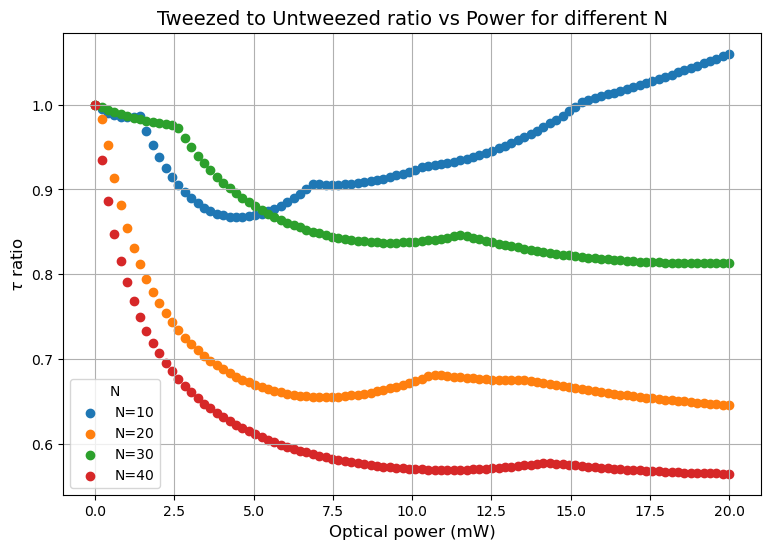

In [135]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 20e-3, 100)
Ns_to_plot = [10, 20, 30,40]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)


# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.scatter(powers_mW, ratio_vals[N_fixed], marker='o', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)",fontsize = 12)
plt.ylabel(r"$\tau$ ratio",fontsize = 12)
plt.title("Tweezed to Untweezed ratio vs Power for different N",fontsize = 14)
plt.grid(True)
plt.legend(title="N")
plt.show()

Minimum ratio for each N:
--------------------------------------------------
N=3: min ratio = 0.968079 at power = 2.0212 mW
N=4: min ratio = 0.857724 at power = 2.0212 mW
N=5: min ratio = 0.986546 at power = 1.5161 mW
N=6: min ratio = 0.828626 at power = 3.0312 mW
N=7: min ratio = 0.801945 at power = 15.6573 mW
N=8: min ratio = 0.720554 at power = 4.0413 mW
N=9: min ratio = 0.961577 at power = 29.7984 mW
N=10: min ratio = 0.867241 at power = 4.5464 mW
N=11: min ratio = 0.690614 at power = 17.6774 mW
N=12: min ratio = 0.672564 at power = 5.0514 mW
N=13: min ratio = 0.968976 at power = 6.5665 mW
N=14: min ratio = 0.811985 at power = 15.6573 mW
N=15: min ratio = 0.759756 at power = 22.2228 mW
N=16: min ratio = 0.844691 at power = 16.6673 mW
N=17: min ratio = 0.884048 at power = 21.2127 mW
N=18: min ratio = 0.738289 at power = 6.5665 mW
N=19: min ratio = 0.923105 at power = 20.2026 mW
N=20: min ratio = 0.638868 at power = 25.7581 mW
N=21: min ratio = 0.796737 at power = 29.2933 mW
N=22: mi

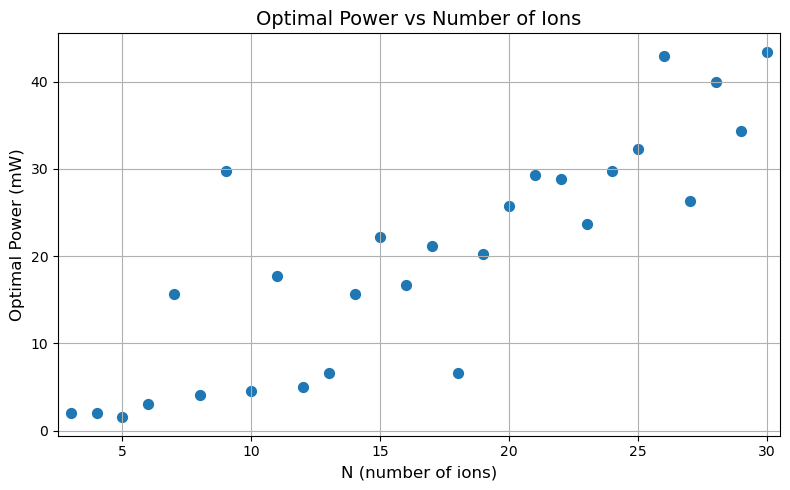

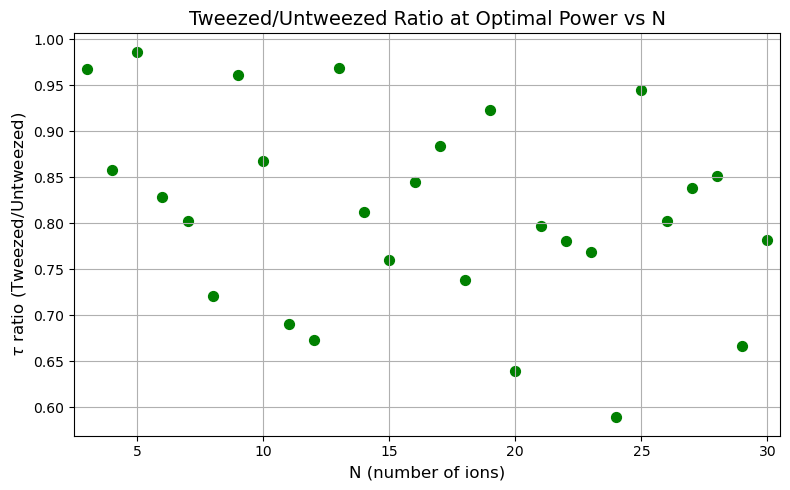

N	Optimal Power (mW)	Ratio at Optimal Power
--------------------------------------------------
3	2.0212		0.968079
4	2.0212		0.857724
5	1.5161		0.986546
6	3.0312		0.828626
7	15.6573		0.801945
8	4.0413		0.720554
9	29.7984		0.961577
10	4.5464		0.867241
11	17.6774		0.690614
12	5.0514		0.672564
13	6.5665		0.968976
14	15.6573		0.811985
15	22.2228		0.759756
16	16.6673		0.844691
17	21.2127		0.884048
18	6.5665		0.738289
19	20.2026		0.923105
20	25.7581		0.638868
21	29.2933		0.796737
22	28.7883		0.780621
23	23.7379		0.768925
24	29.7984		0.588666
25	32.3236		0.945031
26	42.9294		0.802245
27	26.2631		0.837948
28	39.8992		0.850807
29	34.3437		0.666483
30	43.4345		0.781767


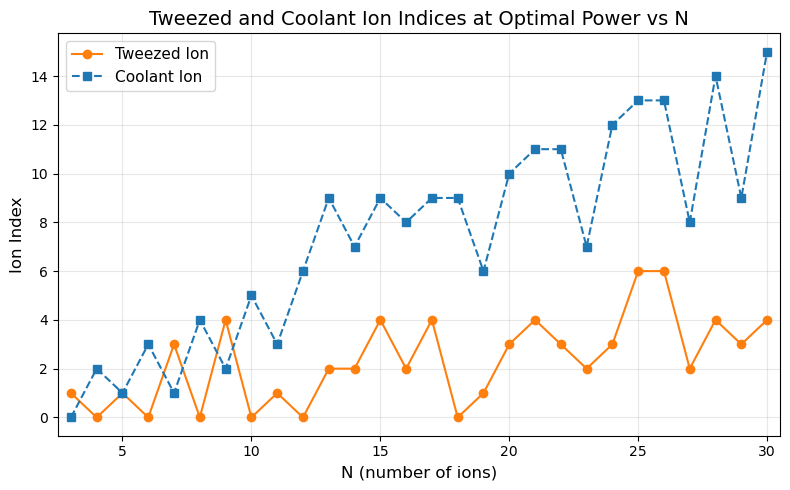

In [147]:
# Example usage: Sweep power and find minima for N=3-31
power_values = np.linspace(1e-6, 50e-3, 100)
Ns_to_sweep = np.arange(3, 31)

results = sweep_power_and_find_minima(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    Ns_to_sweep, f_rf_r, f_rf_a, w0, power_values
)

# Access the results:
t_vals = results['t_vals']
u_vals = results['u_vals']
ratio_vals = results['ratio_vals']
min_power_indices = results['min_power_indices']

# Extract optimal powers for each N
optimal_powers = {N: min_power_indices[N][0] for N in Ns_to_sweep}

# Print minima
print("Minimum ratio for each N:")
print("-" * 50)
for N in Ns_to_sweep:
    min_power, min_ratio = min_power_indices[N]
    print(f"N={N}: min ratio = {min_ratio:.6f} at power = {min_power:.4f} mW")

print("\n")

# ============================================================
# Plot 1: Optimal power vs N
Ns_plot = np.array(list(optimal_powers.keys()))
powers_mW_plot = np.array(list(optimal_powers.values()))

plt.figure(figsize=(8, 5))
plt.scatter(Ns_plot, powers_mW_plot, marker='o', color='C0', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Optimal Power (mW)", fontsize=12)
plt.title("Optimal Power vs Number of Ions", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Ratio at optimal power vs N

# Convert optimal powers to watts for function call
optimal_powers_W = {N: p / 1e3 for N, p in optimal_powers.items()}

dfs = []
dfs_untweezed = []

# Iterate over N and use the optimal P value found for each N
for N in Ns_to_sweep:
    P = optimal_powers_W[N]
    P_current = [P]
    
    # Tweezed
    test_loop = midcircuit_modes_test(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs.append(df)
    
    # Untweezed
    test_loop_u = midcircuit_modes_untweezed_test(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N)
        try:
            dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs_untweezed.append(dfu)

# Combine DataFrames
combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# Calculate the ratio of tweezed to untweezed
common_N = sorted(set(Ns_t).intersection(set(Ns_u)))
ratios = [vals_t[np.where(Ns_t == N)[0][0]] / vals_u[np.where(Ns_u == N)[0][0]] for N in common_N]

# Plot: Ratio at optimal power vs N
plt.figure(figsize=(8, 5))
plt.scatter(common_N, ratios, marker='o', color='green', s=50)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel(r"$\tau$ ratio (Tweezed/Untweezed)", fontsize=12)
plt.title("Tweezed/Untweezed Ratio at Optimal Power vs N", fontsize=14)
plt.grid(True)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# ============================================================
# Print summary table
print("N\tOptimal Power (mW)\tRatio at Optimal Power")
print("-" * 50)
for N in common_N:
    opt_power = optimal_powers[N]
    ratio_val = ratios[common_N.index(N)]
    print(f"{N}\t{opt_power:.4f}\t\t{ratio_val:.6f}")

# ============================================================
# Plot 3: Tweezed Ion and Coolant Ion vs N

tweezed_ions = []
coolant_ions = []
Ns_with_data = []

# Extract tweezed and coolant ions from combined_df
for N in Ns_to_sweep:
    subset = combined_df[combined_df['N'] == N]
    if not subset.empty:
        # Get the first entry for this N
        first_row = subset.iloc[0]
        tweezed_ion = first_row['Tweezed Ion']
        coolant_ion = first_row['Coolant Ion']
        
        # Safely convert to int
        try:
            tweezed_ions.append(int(tweezed_ion) if not pd.isna(tweezed_ion) else np.nan)
        except Exception:
            tweezed_ions.append(np.nan)
        
        try:
            coolant_ions.append(int(coolant_ion) if not pd.isna(coolant_ion) else np.nan)
        except Exception:
            coolant_ions.append(np.nan)
        
        Ns_with_data.append(N)

# Plot tweezed and coolant ions vs N
plt.figure(figsize=(8, 5))
plt.plot(Ns_with_data, tweezed_ions, marker='o', linestyle='-', color='C1', 
         label='Tweezed Ion', markersize=6)
plt.plot(Ns_with_data, coolant_ions, marker='s', linestyle='--', color='C0', 
         label='Coolant Ion', markersize=6)
plt.xlabel("N (number of ions)", fontsize=12)
plt.ylabel("Ion Index", fontsize=12)
plt.title("Tweezed and Coolant Ion Indices at Optimal Power vs N", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(2.5, 30.5)
plt.tight_layout()
plt.show()

# misc tests

In [145]:
coolant_10 = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        10,
        f_rf_r,
        f_rf_a,
        optimal_powers[10],
        w0,
    )

In [146]:
coolant_10

,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,3.0,4,"[0.0002047093105098644, -0.014446545656604803, -0.0024373467384634917, -0.02616650133437983, -0.009161036065562803, 0.036547413476232776, 0.0474270212308779, -0.00419807575254198, 0.05318565149169373, 0.046412591693761156]","[4884.97566382948, 69.22069979703494, 410.28220737702753, 38.21680197979364, 109.1579590827171, 27.361717420859677, 21.085026511193554, 238.20437241859898, 18.802063563255874, 21.545877174844804]",5838.852389


In [ ]:
coolant_3.keys()


Index(['Tweezed Ion', 'Coolant Ion', 'Mode couplings', 'inverse_mode_couplings', 'sum_inverse_middle'], dtype='object')

In [ ]:
Coolant_ions = []
Tweezed_ions = []
for i in range(3,31):
    df = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        i,
        f_rf_r,
        f_rf_a,
        power_values_list[i-3],
        w0,
    )

    # handle missing/empty df
    if not (isinstance(df, pd.DataFrame) and not df.empty):
        Coolant_ions.append(np.nan)
        Tweezed_ions.append(np.nan)
        continue

    # safely extract the first-row scalar values
    cool_val = df['Coolant Ion'].iloc[0] if 'Coolant Ion' in df.columns else np.nan
    tweez_val = df['Tweezed Ion'].iloc[0] if 'Tweezed Ion' in df.columns else np.nan

    # convert to int when safe, otherwise store NaN
    def to_int_safe(x):
        try:
            if pd.isna(x):
                return np.nan
            return int(x)
        except Exception:
            try:
                return int(float(x))
            except Exception:
                return np.nan

    Coolant_ions.append(to_int_safe(cool_val))
    Tweezed_ions.append(to_int_safe(tweez_val))


In [ ]:
print(Coolant_ions)
print(Tweezed_ions)

[0, 3, 1, 1, 2, 5, 2, 3, 3, 5, 3, 8, 5, 5, 4, 11, 6, 10, 11, 11, 12, 12, 13, 13, 16, 14, 9, 15]
[1, 1, 1, 0, 1, 1, 0, 1, 5, 2, 0, 2, 3, 2, 8, 5, 2, 4, 8, 6, 7, 5, 8, 6, 9, 4, 3, 4]


In [ ]:
N10untweezed = midcircuit_modes_untweezed_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        10,
        f_rf_r,
        f_rf_a,
        100e-3,
        w0,
    )

In [ ]:
N10untweezed

,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,NaN,3,"[0.03065025357164199, -0.01484264581003048, -0.024697085298224085, 0.02939873438876856, -0.009469543794818147, -0.03861452576682569, 0.017537452017529775, 0.030139199291677462, 0.05319336563494841, -0.035981524943573685]","[32.62615748553588, 67.37343279620754, 40.49060801810114, 34.01506972293468, 105.60170813584625, 25.89699032013271, 57.020826001430414, 33.17938178523995, 18.79933687337492, 27.79204054214496]",442.795552
1,NaN,6,"[0.030650253571639505, 0.014842645809876594, -0.024697085299029066, -0.029398734387378375, -0.00946954379749398, 0.03861452576690534, 0.017537452017334847, -0.03013919929138898, 0.05319336563497979, 0.03598152494372811]","[32.62615748553852, 67.37343279690606, 40.49060801678139, 34.01506972454316, 105.60170810600613, 25.89699032007929, 57.02082600206419, 33.17938178555753, 18.79933687336383, 27.79204054202568]",442.795552


# Using optimal power for N=10 to make a verticle color bar table

In [ ]:
N = 20
P = 100e-3
N10Test = midcircuit_modes_test(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     f_rf_a,
                     P,
                     w0
                     )

In [ ]:
print(N10Test)

   Tweezed Ion  Coolant Ion                                                                                                                                                                                                                                                                                                                                                                                                                                                 Mode couplings                                                                                                                                                                                                                                                                                                                                                                              inverse_mode_couplings  sum_inverse_middle
0          4.0            6  [-0.01336169062907159, 0.006660583168020019, 0.0045084428501570226, 0.012462498001871483